In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import bootstrap
from numba import njit
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import LeaveOneOut, GridSearchCV

ds = np.loadtxt('sdss_cutout.csv', skiprows=1, delimiter=',')

In [4]:
ds_panda = pd.read_csv('sdss_cutout.csv')
ds_panda

,RA,DEC,Z,phot_u,phot_g,phot_r,phot_i,phot_z
0,130.089951,52.178097,0.097629,19.854843,18.159964,17.345013,16.930433,16.620535
1,130.173909,52.557767,0.067737,19.250399,17.239248,16.517265,16.083832,15.822161
2,130.081237,52.668188,0.063350,18.680342,17.206959,16.697826,16.362032,16.173033
3,130.291706,52.572373,0.065425,19.726742,17.791235,16.906610,16.495539,16.182104
4,130.013537,52.766588,0.123360,19.386818,17.534359,16.450377,15.943369,15.545097
...,...,...,...,...,...,...,...,...
319953,149.580633,47.033396,0.390038,23.223936,19.346468,17.534588,16.857544,16.351515
319954,150.261929,46.827647,0.204686,20.360432,18.511255,17.276648,16.812563,16.496658
319955,149.937963,46.482358,0.102099,19.087252,17.185118,16.237055,15.844631,15.480799
319956,150.023597,46.260926,0.069142,19.072407,17.949339,17.497790,17.227016,17.132250


In [5]:
ds2 = np.array([ds[0,:]])
for n in range(1, np.shape(ds)[0]):
    if (ds[n,2] < 0.105 and ds[n,2] > 0.095):
        ds2 = np.append(ds2, np.array([ds[n,:]]), axis = 0)

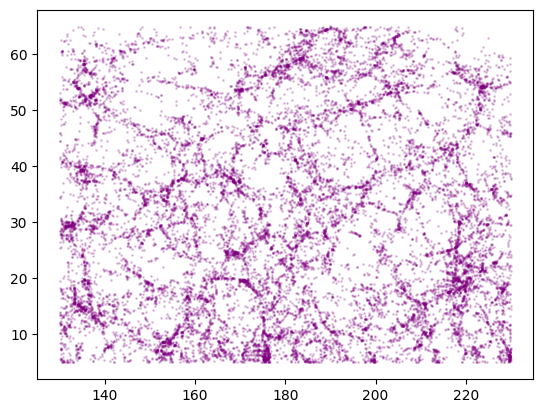

In [5]:
plt.scatter(ds2[:,0], ds2[:,1], s=1, alpha=0.2, color = "purple")

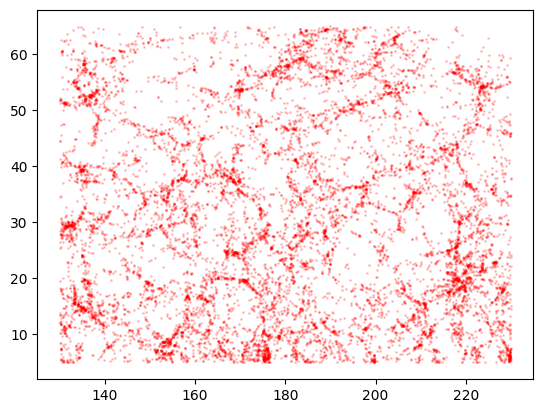

In [7]:
plt.scatter(redgalaxies[:,0], redgalaxies[:,1], s=1, alpha=0.2, color = "red")

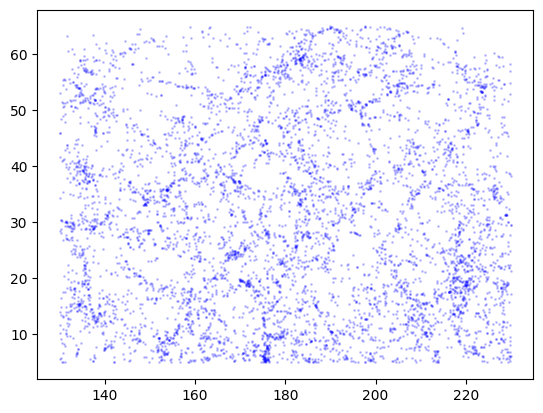

In [8]:
plt.scatter(bluegalaxies[:,0], bluegalaxies[:,1], s=1, alpha=0.2, color = "blue")

In [9]:
print(ds2[:, 0].min(), ds2[:, 0].max())  # RA range
print(ds2[:, 1].min(), ds2[:, 1].max())  # DEC range
print(ds2.shape)                          # how many galaxies

130.00716750663128 229.99580238242615
5.002095975017483 64.9815952201038
(20325, 8)


In [13]:

# downsample to make LOO feasible
np.random.seed(42)
idx = np.random.choice(len(ds2), size=2000, replace=False)
Xdata = ds2[idx, :2]  # just RA and DEC, shape (2000, 2)

# LOO grid search
bandwidths = np.geomspace(0.05, 2.0, 30)
grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                    {'bandwidth': bandwidths}, cv=LeaveOneOut())
grid.fit(Xdata)
h_opt = grid.best_params_['bandwidth'] 

# Silverman's rule: sigma = geometric mean of marginal stds
sigma = np.sqrt(np.std(Xdata[:,0]) * np.std(Xdata[:,1]))
N = len(Xdata)
h_silv = 1.06 * sigma * N**(-1/5)
print(f"h_opt  = {h_opt:.3f}°")
print(f"h_silv = {h_silv:.3f}°")

h_opt  = 1.059°
h_silv = 5.189°


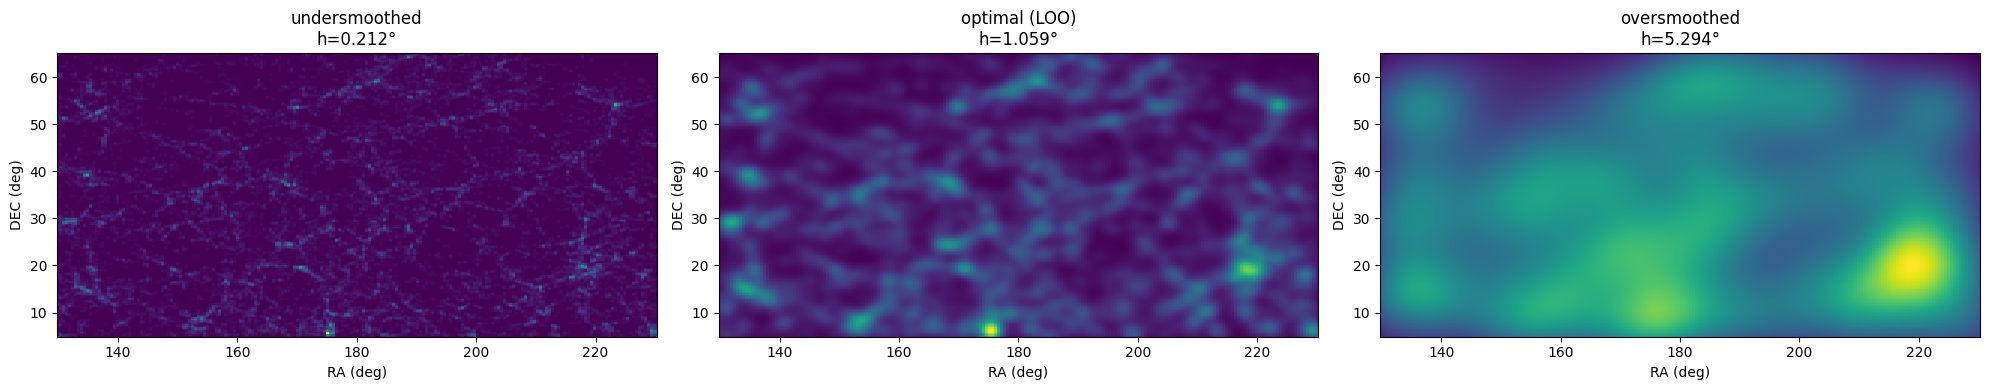

In [ ]:
# fit final models on full Xdata (all galaxies, not downsampled)
Xdata_full = ds2[:, :2]

bandwidths_to_plot = [h_opt/5, h_opt, h_opt*5]
titles = [f'undersmoothed\nh={h_opt/5:.3f}°', 
          f'optimal (LOO)\nh={h_opt:.3f}°', 
          f'oversmoothed\nh={h_opt*5:.3f}°']

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

n1, n2 = 200, 200
v1min, v1max = Xdata_full[:, 0].min(), Xdata_full[:, 0].max()
v2min, v2max = Xdata_full[:, 1].min(), Xdata_full[:, 1].max()

v1g = np.linspace(v1min, v1max, n1)
v2g = np.linspace(v2min, v2max, n2)
xg, yg = np.meshgrid(v1g, v2g)
Xgrid = np.vstack((xg.flatten(), yg.flatten())).T

for ax, h, title in zip(axes, bandwidths_to_plot, titles):
    model = KernelDensity(kernel='gaussian', bandwidth=h)
    model.fit(Xdata_full)
    kde_dens_at_x = np.exp(model.score_samples(Xgrid))
    ptest = kde_dens_at_x.reshape((n2, n1))
    ax.pcolor(v1g, v2g, ptest, cmap='viridis')
    ax.set_xlabel('RA (deg)')
    ax.set_ylabel('DEC (deg)')
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [6]:
u_r = ds2[:, 3] - ds2[:, 5]

ds2 = np.column_stack((ds2, u_r))

n=1, BIC=28758.72
n=2, BIC=24667.15
n=3, BIC=24800.50
n=4, BIC=22449.05
n=5, BIC=22475.39
n=6, BIC=22467.34


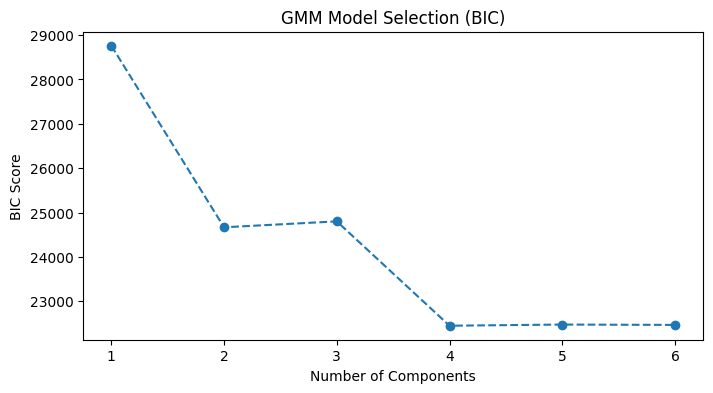

In [34]:

bics = []
n_components = range(1, 7)
for n in n_components:
    gmm = GaussianMixture(n_components=n, covariance_type='full',n_init=100, random_state=31,
    reg_covar=1e-3)  # add small regularization to avoid singular covariances
    gmm.fit(ds2[:,8:9])
    bic = gmm.bic(ds2[:,8:9])
    aic = gmm.aic(ds2[:,8:9])
    bics.append(bic)
    print(f"n={n}, BIC={bic:.2f}")
plt.figure(figsize=(8, 4))
plt.plot(n_components, bics, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('BIC Score')
plt.title('GMM Model Selection (BIC)')
plt.show()
    

Biggest drop is at 2 with -4093 and second drop is at 4 with -2364 after K=4 the drop or becomes either negligable or it turns into an increase.

In [24]:
Diff_bics = np.diff(bics) 
print("BIC differences at steps:", Diff_bics)

BIC differences at steps: [-4093.12189741   150.92136653 -2360.50710064    26.80087925
    54.69191062]


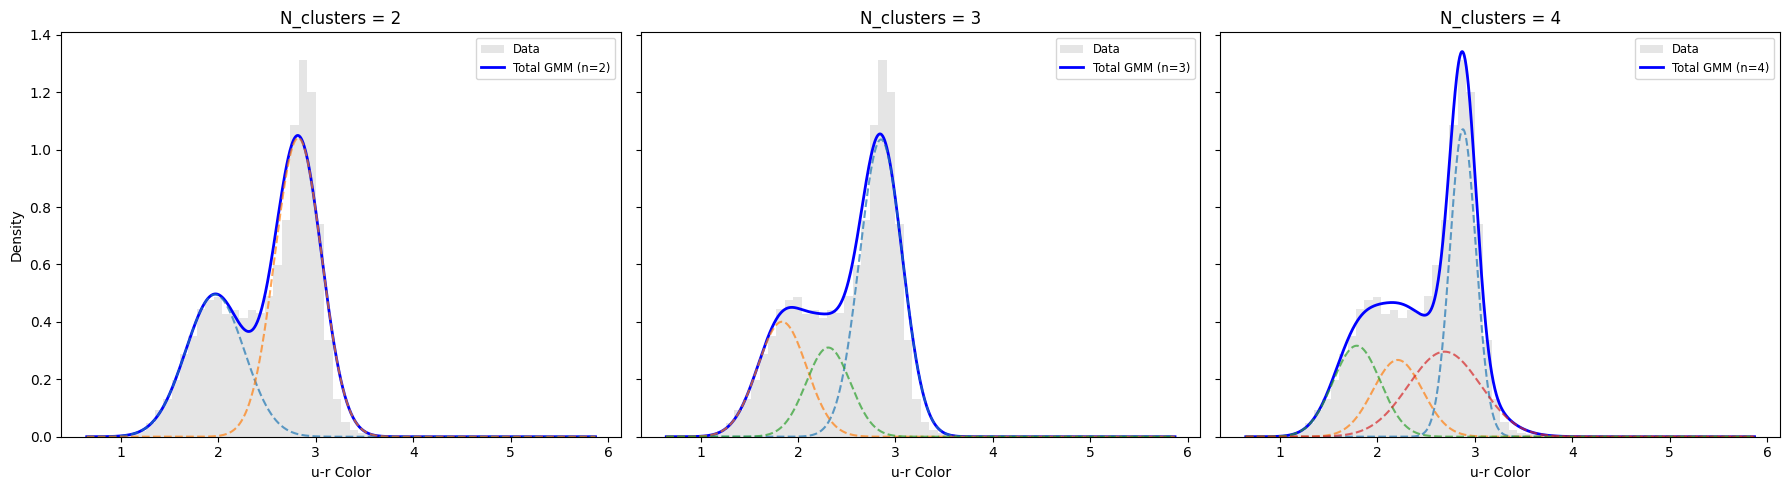

In [44]:
# 1. Define the number of components you want to compare
n_values = [2,3,4]
models = {}  # Dictionary to store the fitted models for later use

# 2. Setup the figure for subplots
fig, axes = plt.subplots(1, len(n_values), figsize=(18, 5), sharey=True)
x_plot = np.linspace(ds2[:, 8].min(), ds2[:, 8].max(), 1000).reshape(-1, 1)

for i, n in enumerate(n_values):
    # Fit the model
    gmm = GaussianMixture(n_components=n, n_init=20, random_state=31).fit(ds2[:, 8].reshape(-1, 1))
    models[n] = gmm # Save to our list/dictionary
    
    # Calculate density
    log_density = gmm.score_samples(x_plot)
    total_density = np.exp(log_density)
    
    # Plotting on the specific subplot (axes[i])
    ax = axes[i]
    ax.hist(ds2[:, 8], bins=60, density=True, alpha=0.2, color='gray', label='Data')
    ax.plot(x_plot, total_density, color='blue', lw=2, label=f'Total GMM (n={n})')
    
    # Plot individual components
    resp = gmm.predict_proba(x_plot)
    individual_densities = resp * total_density[:, np.newaxis]
    for j in range(n):
        ax.plot(x_plot, individual_densities[:, j], '--', alpha=0.7)
        
    ax.set_title(f'N_clusters = {n}')
    ax.set_xlabel('u-r Color')
    if i == 0: ax.set_ylabel('Density')
    ax.legend(fontsize='small')

plt.tight_layout()
plt.show()

In [48]:
chosen_n = 4
chosen_model = GaussianMixture(n_components=chosen_n, covariance_type='full', n_init=20, random_state=31)
chosen_model.fit(ds2[:,8:9])
reddest_idx = np.argmax(chosen_model.means_)
tau_red = chosen_model.predict_proba(ds2[:, 8:9])[:, reddest_idx]


Text(0.5, 1.0, 'GMM Classification of Red vs Blue Galaxies')

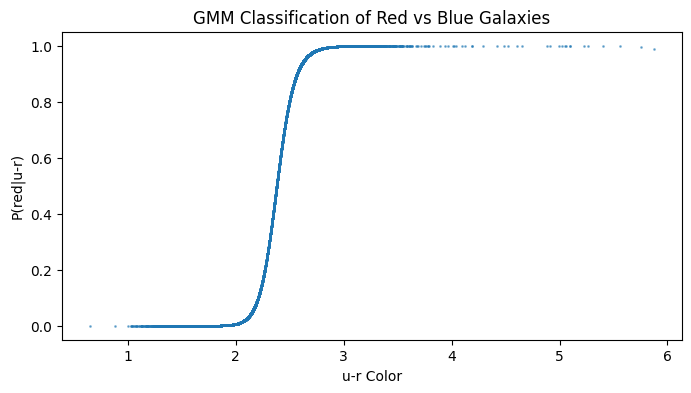

In [46]:
plt.figure(figsize=(8, 4))
plt.scatter(ds2[:,8], tau_red, s=1, alpha=0.5)
plt.xlabel('u-r Color') 
plt.ylabel('P(red|u-r)')
plt.title('GMM Classification of Red vs Blue Galaxies')

We know that there are 2 distinct clusters of galaxies, namely blue and red ones and theres a grey are in between called the green valley where both red and blue galaxies might live. Choosing N = 2, with 2 gaussians we are able to capture the green valley just as well if we were to fit a 3rd gaussian in the middle, N = 4 shows the best fit as it uses 2 gaussians with lower peaks to capture the edge cases and 2 with higher peaks to capture the more dense regions, statistically choosing N = 4 would be the best choice for estimating the empirical dist. however for interpratibility and for the classification purpose we are given in the task N = 2 makes more sense. Comparing the classification probabilities with the hard cut-off, we can see that the galaxies in the green valley region are not classified as red or blue with P=1, so we have now given them probabilities of belonging to each of the classes respectively.